# Кейс №6

## Прогнозирование исходов заболевания циррозом печени с помощью ML

## Участники:

- Алёна Лозинская
- Валентина Кулакова
- Дмитрий Волобуев
- Артур Григорян
- Ильсия Коткова
- Матвей Радаев

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [2]:
plt.style.use("default")
sns.set_palette("Set2")

RANDOM_STATE = 42
TARGET_COL = "Status"
DROP_COL = ["id", "N_Days"]

# Этап I. Предобработка данных для ML

Загрузим данные, разделим наши признаки на числовые и категориальные, преобразуем таргет в бинарный, разделим на train и test.

In [3]:
df = pd.read_csv("../../data/train.csv").drop(columns=DROP_COL)

In [4]:
target_maps = {"C": 0, "D": 1}

binary_maps = {
    "Drug": {"Placebo": 0, "D-penicillamine": 1},
    "Sex": {"F": 0, "M": 1},
    "Ascites": {"N": 0, "Y": 1},
    "Hepatomegaly": {"N": 0, "Y": 1},
    "Spiders": {"N": 0, "Y": 1}
}

binary_features = list(binary_maps.keys())
multi_category_features = ["Edema", "Stage"]

numeric_features = ["Age", "Bilirubin", "Cholesterol", "Albumin", "Copper",
                    "Alk_Phos", "SGOT", "Tryglicerides", "Platelets", "Prothrombin"]

Исходный таргет с тремя категориями преобразуем в две и будем решать задачу бинарной классификации.

Класс CL означает, что пациент выжил благодаря трансплантации печени. А информации о том, кому была сделана или назначена трансплантация, в данных нет. Поэтому мы не можем корректно предсказать событие CL по исходным биохимическим показателям - оно зависит не только от тяжести болезни, но и от внешних факторов (решение врача, наличие органа, успешность операции). Среди представителей класса D также могли быть пациенты, которые перенесли трансплантацию печени, равно как и в классе C могут быть пациенты, которым предстоит операция, но мы об этом не знаем. Кроме того, CL очень малочисленный: всего 3.5% против 33.7% и 62.8% классов D и C соответственно. Поэтому его разумно исключить и решать задачу в виде бинарной классификации:

- Класс 0, умеренная стадия заболевания — C (пациент жив)
- Класс 1, тяжёлая стадия заболевания — D (летальный исход)

In [5]:
df = df[df[TARGET_COL] != 'CL'].reset_index(drop=True)

df[TARGET_COL] = df[TARGET_COL].map(target_maps)

df[TARGET_COL].value_counts(normalize=True)

Status
0    0.650721
1    0.349279
Name: proportion, dtype: float64

Разделим все данные на train и test. Подбор методов обработки признаков, настройку гиперпараметров и оценку качества будем проводить только на кросс-валидации на train. Test служит для финальной оценки качества лучшей модели.

In [6]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [7]:
print("Распределение таргета на train:")
print(y_train.value_counts(normalize=True))

print("=="*25)

print("Распределение таргета на test:")
print(y_test.value_counts(normalize=True))

Распределение таргета на train:
Status
0    0.650721
1    0.349279
Name: proportion, dtype: float64
Распределение таргета на test:
Status
0    0.650721
1    0.349279
Name: proportion, dtype: float64


Числовые признаки оставим в исходном виде, поскольку ML-модели на основе деревьев не накладывают жёстких требований в виде масштабирования, коррекции асимметрии и борьбы с выбросами. Поэтому в качестве обработки признаков закодируем только категориальные фичи:

- бинарные как 0 и 1
- Edema и Stage через OrdinalEncoder

In [8]:
class BinaryMapper(BaseEstimator, TransformerMixin):
    """
    Превращает бинарные категориальные в 0/1 по заданному словарю.
    """
    def __init__(self, mapping: dict):
        self.mapping = mapping
        self.columns_ = list(mapping.keys())

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=self.columns_)
        for col, mapping in self.mapping.items():
            X_df[col] = X_df[col].map(mapping)
        return X_df

    def get_feature_names_out(self, input_features=None):
        return self.columns_

In [9]:
def make_tree_processor(binary_maps, binary_features, multi_category_features):
    
    processor = ColumnTransformer(
        transformers=[
            ("binary", BinaryMapper(binary_maps), binary_features),
            ("category", OrdinalEncoder(), multi_category_features)
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )
    
    return processor

Будем использовать StratifiedKFold, чтобы в каждом фолде была соблюдена пропорция классов. Установим 5 фолдов.

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Этап II. Decision Tree

Напишем вспомогательные функции для создания общего пайплайна и подбора гиперпараметров (включая методы сэмплирования для борьбы с дисбалансом классов) через GridSearch. В функции с созданием пайплайнов можно передавать базовый processor для категориальных переменных, а также флаг use_fe - значение True позволяет добавить в предобработку дополнительные шаги в случае feature engineering.

In [11]:
def make_tree_gridsearch(
    preprocessor=None,
    use_fe=False,
    fe_cols=None
):
    
    samplers = [
        "passthrough",
        RandomUnderSampler(random_state=RANDOM_STATE),
        RandomOverSampler(random_state=RANDOM_STATE),
        SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    ]
    
    dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
    
    steps = []
    
    if use_fe:

        if not fe_cols:
            fe_cols = ["Symptom_Score", "Bilirubin_Albumin_Ratio", "Coagulation_Index", "Enzyme_Pattern"]

        if "Symptom_Score" in fe_cols:
            steps.append(("symptom_score", SymptomScoreTransformer()))
        if "Bilirubin_Albumin_Ratio" in fe_cols:
            steps.append(("bilirubin_albumin_ratio", BilirubinAlbuminRatioTransformer()))
        if "Coagulation_Index" in fe_cols:
            steps.append(("coagulation_index", CoagulationIndexTransformer()))
        if "Enzyme_Pattern" in fe_cols:
            steps.append(("enzyme_pattern", EnzymePatternTransformer()))

    steps.extend([
        ("preprocess", preprocessor),
        ("sampler", "passthrough"),
        ("dt", dt)
    ])

    pipe = ImbPipeline(steps)
    
    param_grid = {
        'sampler': samplers,
        'dt__max_depth': [3, 5, 7, 10, None],
        'dt__min_samples_split': [2, 5, 10, 15],
        'dt__min_samples_leaf': [1, 5, 10, 15, 20],
        'dt__max_features': [None, 'sqrt', 'log2'],
        'dt__criterion': ['gini', 'entropy'],
        'dt__class_weight': [None, 'balanced']
    }
    
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=skf,
        scoring="recall",
        n_jobs=-1
    )
    
    return gs

Напишем вспомогательные функции для визуализаций

In [12]:
# нарисовать дерево
def plot_tree_from_estimator(estimator, tree_step_name="dt"):

    if hasattr(estimator, "best_estimator_"):
        pipe = estimator.best_estimator_
    else:
        pipe = estimator

    tree_clf = pipe.named_steps[tree_step_name]
    preprocess = pipe.named_steps["preprocess"]
    feature_names = preprocess.get_feature_names_out()

    plt.figure(figsize=(24, 12), dpi=300)
    plot_tree(
        tree_clf,
        feature_names=feature_names,
        class_names=["0", "1"],
        filled=True,
        rounded=True
    )
    plt.show()


# барплот важности признаков
def plot_feature_importances(estimator, model_step_name="dt", top_n=None, title="Важность признаков"):

    if hasattr(estimator, "best_estimator_"):
        pipe = estimator.best_estimator_
    else:
        pipe = estimator

    model = pipe.named_steps[model_step_name]
    preprocess = pipe.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()
    importances = model.feature_importances_

    df_imp = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

    if top_n is not None:
        df_imp = df_imp.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_imp, y="feature", x="importance")
    plt.xlabel("Важность признака")
    plt.ylabel("Признак")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_imp


# кривые precision, recall, F1 в зависимости от порога
def plot_threshold_curves(estimator, X, y, cv, title="Зависимость метрик от порога"):

    if hasattr(estimator, "best_estimator_"):
        model = estimator.best_estimator_
    else:
        model = estimator

    y_proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

    thresholds = np.arange(0.1, 0.91, 0.05)
    recalls, precisions, f1s = [], [], []

    for thr in thresholds:
        y_thr = (y_proba >= thr).astype(int)
        recalls.append(recall_score(y, y_thr))
        precisions.append(precision_score(y, y_thr))
        f1s.append(f1_score(y, y_thr))

    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, recalls, label="Recall")
    plt.plot(thresholds, precisions, label="Precision")
    plt.plot(thresholds, f1s, label="F1")
    plt.xlabel("Порог вероятности")
    plt.ylabel("Метрика")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# матрица ошибок
def plot_confusion_matrix_simple(y_true, y_pred, title="Матрица ошибок"):
    
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

## 1. DT

In [13]:
processor = make_tree_processor(binary_maps, binary_features, multi_category_features)
gs_dt = make_tree_gridsearch(preprocessor=processor, use_fe=False)

gs_dt.fit(X_train, y_train)
print("Дерево решений:")
print("Лучшие параметры:", gs_dt.best_params_)
print("Лучший recall на кросс-валидации:", gs_dt.best_score_)

Дерево решений:
Лучшие параметры: {'dt__class_weight': 'balanced', 'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2, 'sampler': 'passthrough'}
Лучший recall на кросс-валидации: 0.8461512242856044


In [14]:
y_pred_dt = cross_val_predict(
    gs_dt.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

print("Отчёт по классам (модель decision tree):")
print(classification_report(y_train, y_pred_dt))

Отчёт по классам (модель decision tree):
              precision    recall  f1-score   support

           0       0.89      0.67      0.76      3972
           1       0.58      0.85      0.69      2132

    accuracy                           0.73      6104
   macro avg       0.73      0.76      0.73      6104
weighted avg       0.78      0.73      0.74      6104



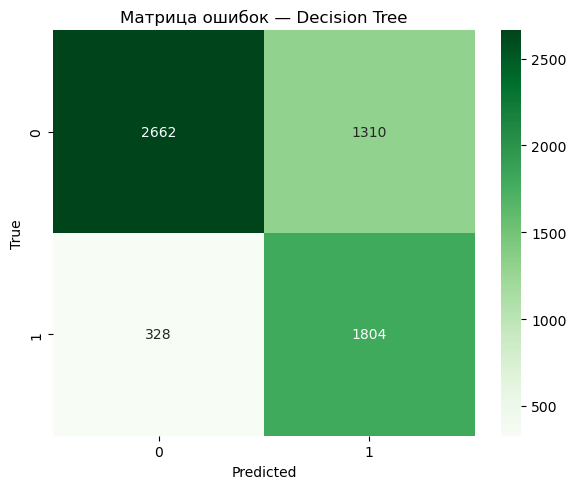

In [15]:
plot_confusion_matrix_simple(y_train, y_pred_dt, title="Матрица ошибок — Decision Tree")

На данный момент оптимальной по балансу метрик recall и precision является модель *Decision Tree с весами классов*:

- recall - 0.85
- precision - 0.58

Можем получить информацию о логике работы решающего дерева в графическом виде. На практике данный подход позволил бы легко и точно интерпретировать решения модели.

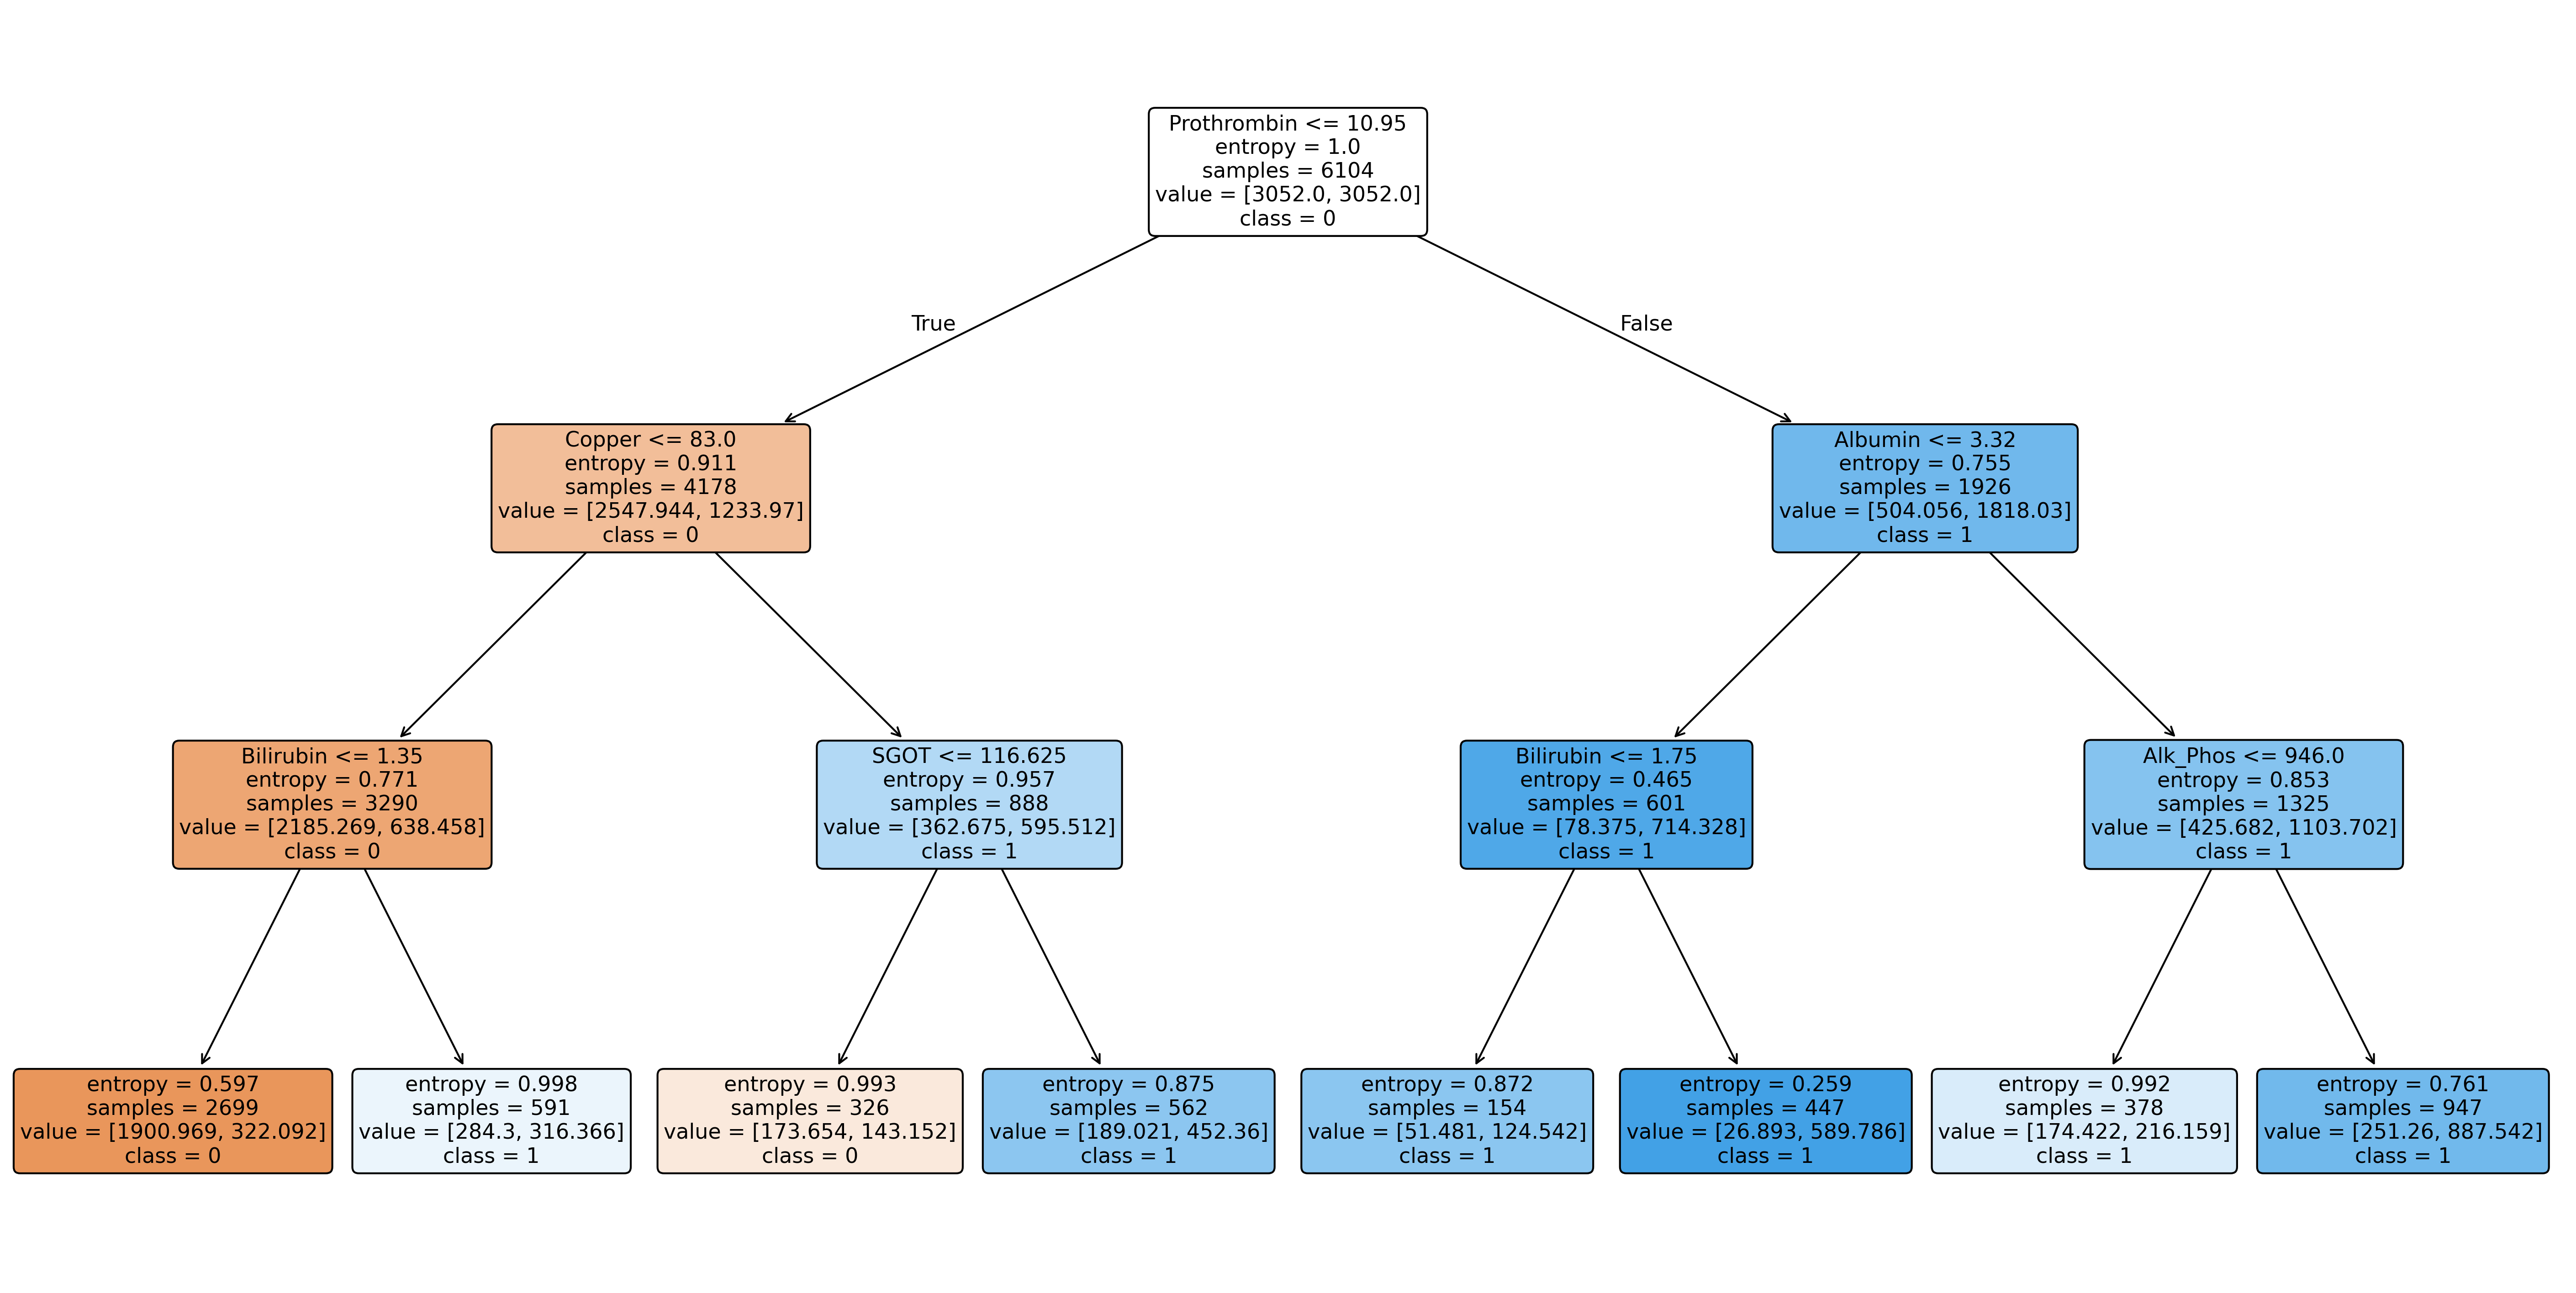

In [16]:
plot_tree_from_estimator(gs_dt)

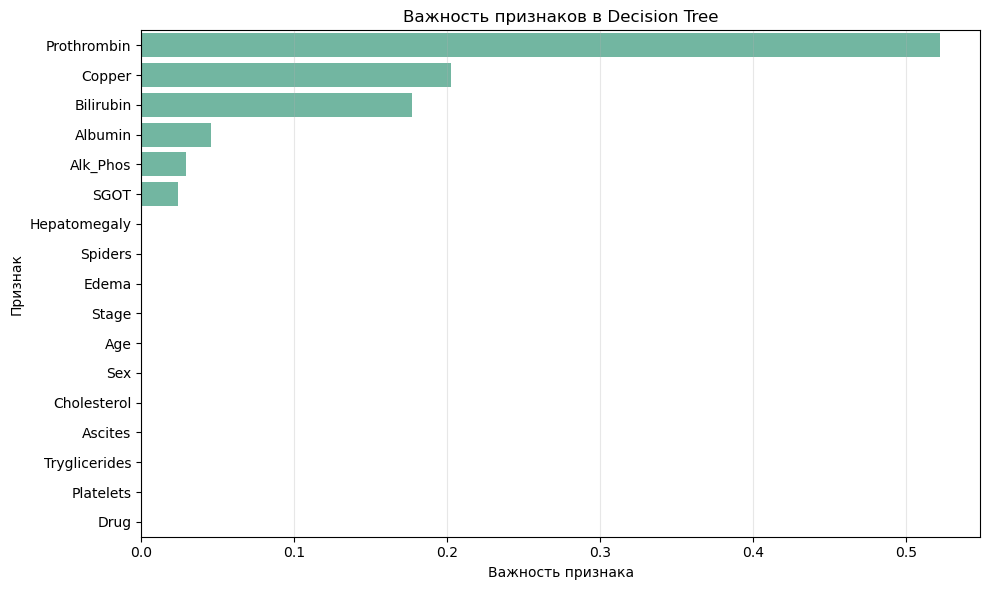

,feature,importance
16,Prothrombin,0.522132
11,Copper,0.202426
8,Bilirubin,0.177074
10,Albumin,0.045494
12,Alk_Phos,0.029097
13,SGOT,0.023777
3,Hepatomegaly,0.000000
4,Spiders,0.000000
5,Edema,0.000000
6,Stage,0.000000


In [17]:
plot_feature_importances(gs_dt,
                         title="Важность признаков в Decision Tree"
                        )

Попробуем исключить признаки с нулевой значимостью и проверим качество на кросс-валидации.

In [18]:
cols_to_drop = ['Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders',
                'Edema', 'Cholesterol', 'Tryglicerides', 'Platelets', 'Stage']

X_train_new = X_train.drop(cols_to_drop, axis=1).copy()

processor_short = make_tree_processor(binary_maps={}, binary_features=[], multi_category_features=[])

gs_dt_short = make_tree_gridsearch(preprocessor=processor_short, use_fe=False)

gs_dt_short.fit(X_train_new, y_train)
print("Дерево решений (без части признаков):")
print("Лучшие параметры:", gs_dt_short.best_params_)
print("Лучший recall на кросс-валидации:", gs_dt_short.best_score_)

Дерево решений (без части признаков):
Лучшие параметры: {'dt__class_weight': 'balanced', 'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2, 'sampler': 'passthrough'}
Лучший recall на кросс-валидации: 0.8020714450638255


In [19]:
y_pred_dt_short = cross_val_predict(
    gs_dt_short.best_estimator_,
    X_train_new, y_train,
    cv=skf,
    n_jobs=-1
)

print("Отчёт по классам (модель decision tree):")
print(classification_report(y_train, y_pred_dt_short))

Отчёт по классам (модель decision tree):
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      3972
           1       0.65      0.80      0.72      2132

    accuracy                           0.78      6104
   macro avg       0.76      0.78      0.77      6104
weighted avg       0.80      0.78      0.78      6104



Видим, что удаление части признаков привело к значительному улучшению precision, однако ключевая метрика recall снизилась на 5 единиц. Вернёмся к исходному набору признаков и попробуем подобрать порог, чтобы максимизировать recall, но не сильно потерять в precision.

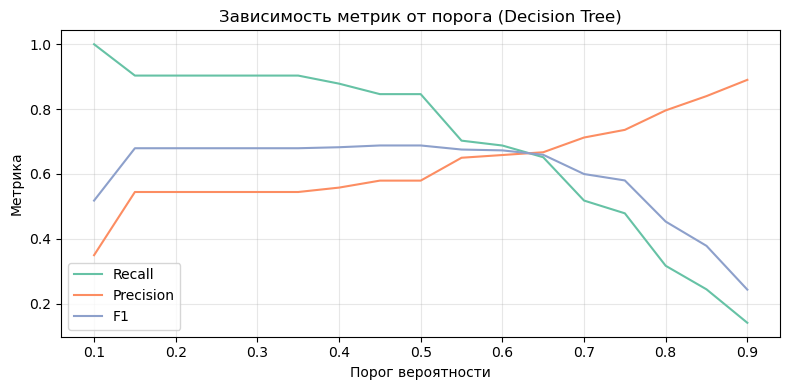

In [20]:
plot_threshold_curves(gs_dt, X_train, y_train, cv=skf,
                      title="Зависимость метрик от порога (Decision Tree)")

In [21]:
THRESHOLD = 0.35

y_proba_dt = cross_val_predict(
    gs_dt.best_estimator_,
    X_train, y_train,
    method="predict_proba",
    cv=skf,
    n_jobs=-1
)[:, 1]

y_pred_dt_thr = (y_proba_dt >= THRESHOLD).astype(int)

print(f"Отчёт по классам (модель с весами классов и порогом {THRESHOLD}):")
print(classification_report(y_train, y_pred_dt_thr))

Отчёт по классам (модель с весами классов и порогом 0.35):
              precision    recall  f1-score   support

           0       0.92      0.59      0.72      3972
           1       0.54      0.90      0.68      2132

    accuracy                           0.70      6104
   macro avg       0.73      0.75      0.70      6104
weighted avg       0.79      0.70      0.71      6104



## 2. DT + Feature Engineering

Попробуем сгенерировать дополнительные признаки, которые могут улучшить качество модели

In [22]:
class SymptomScoreTransformer(BaseEstimator, TransformerMixin):
    """
    Symptom_Score - суммарное кол-во осложнений (Ascites, Hepatomegaly, Spiders, Edema)
    """
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        X = X.copy()
        mapping = {'N': 0, 'Y': 1, 'S': 1}

        ascites = X['Ascites'].map(mapping)
        hepatomegaly = X['Hepatomegaly'].map(mapping)
        spiders = X['Spiders'].map(mapping)
        edema = X['Edema'].map(mapping)

        X['Symptom_Score'] = ascites + hepatomegaly + spiders + edema
        return X
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        input_features = list(input_features)
        return np.array(input_features + ["Symptom_Score"], dtype=object)


class BilirubinAlbuminRatioTransformer(BaseEstimator, TransformerMixin):
    """
    Bilirubin_Albumin_Ratio = Bilirubin / Albumin
    """
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        X = X.copy()
        eps = 1e-6
        X['Bilirubin_Albumin_Ratio'] = X['Bilirubin'] / (X['Albumin'] + eps)
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array(list(input_features) + ["Bilirubin_Albumin_Ratio"], dtype=object)
    

class CoagulationIndexTransformer(BaseEstimator, TransformerMixin):
    """
    Coagulation_Index = Prothrombin / Albumin (показатель синтетической функции печени)*
    """
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        X = X.copy()
        eps = 1e-6
        X['Coagulation_Index'] = X['Prothrombin'] / (X['Albumin'] + eps)
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array(list(input_features) + ["Coagulation_Index"], dtype=object)
    

class EnzymePatternTransformer(BaseEstimator, TransformerMixin):
    """
    Добавляет Enzyme_Pattern = SGOT / Alk_Phos (тип поражения печени)*
    """
    def fit(self, X, y=None):
        self.feature_names_in_ = X.columns.to_list()
        return self

    def transform(self, X):
        X = X.copy()
        eps = 1e-6
        X['Enzyme_Pattern'] = X['SGOT'] / (X['Alk_Phos'] + eps)
        return X
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array(list(input_features) + ["Enzyme_Pattern"], dtype=object)

In [23]:
processor_fe = make_tree_processor(binary_maps, binary_features, multi_category_features)
gs_dt_fe = make_tree_gridsearch(preprocessor=processor_fe, use_fe=True)

gs_dt_fe.fit(X_train, y_train)
print("Дерево решений (FE):")
print("Лучшие параметры:", gs_dt_fe.best_params_)
print("Лучший recall на кросс-валидации:", gs_dt_fe.best_score_)

Дерево решений (FE):
Лучшие параметры: {'dt__class_weight': 'balanced', 'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__max_features': None, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2, 'sampler': 'passthrough'}
Лучший recall на кросс-валидации: 0.7987762641422305


In [24]:
y_pred_dt_fe = cross_val_predict(
    gs_dt_fe.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

print("Отчёт по классам (модель decision tree с FE):")
print(classification_report(y_train, y_pred_dt_fe))

Отчёт по классам (модель decision tree с FE):
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      3972
           1       0.65      0.80      0.72      2132

    accuracy                           0.78      6104
   macro avg       0.77      0.79      0.77      6104
weighted avg       0.80      0.78      0.79      6104



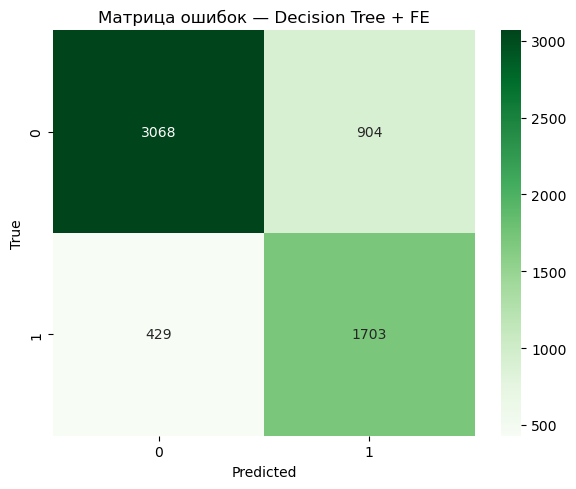

In [25]:
plot_confusion_matrix_simple(y_train, y_pred_dt_fe,
                             title="Матрица ошибок — Decision Tree + FE")

Видим, что использование полного набора признаков позволило получить примерно такое же качество, как при удалении некоторых фичей из исходного датасета: вырос precision, но есть снижение на 5 единиц по ключевой метрике recall.

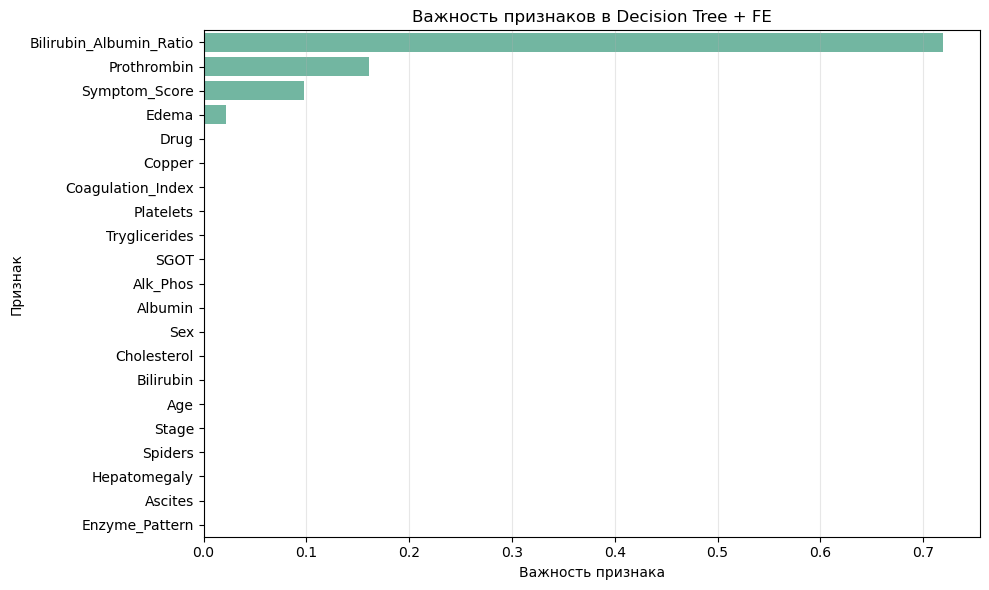

,feature,importance
18,Bilirubin_Albumin_Ratio,0.719451
16,Prothrombin,0.161063
17,Symptom_Score,0.097992
5,Edema,0.021495
0,Drug,0.000000
11,Copper,0.000000
19,Coagulation_Index,0.000000
15,Platelets,0.000000
14,Tryglicerides,0.000000
13,SGOT,0.000000


In [26]:
plot_feature_importances(gs_dt_fe,
                         title="Важность признаков в Decision Tree + FE")

Попробуем провести эксперимент и удалить часть незначимых признаков. Исключение из датасета избыточных признаков может потенциально улучшить качество модели.

In [27]:
cols_to_drop = ['Drug', 'Age', 'Sex', 'Cholesterol', 'Copper',
                'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Stage']

X_train_new = X_train.drop(cols_to_drop, axis=1).copy()

binary_maps_new = {
    "Ascites": {"N": 0, "Y": 1},
    "Hepatomegaly": {"N": 0, "Y": 1},
    "Spiders": {"N": 0, "Y": 1}
}


processor_fe_new = make_tree_processor(binary_maps=binary_maps_new,
                                       binary_features=list(binary_maps_new.keys()),
                                       multi_category_features=['Edema'])

gs_dt_fe_new = make_tree_gridsearch(preprocessor=processor_fe_new,
                                    use_fe=True,
                                    fe_cols=['Bilirubin_Albumin_Ratio', 'Symptom_Score'])

gs_dt_fe_new.fit(X_train_new, y_train)
print("DT + FE (без части признаков):")
print("Лучшие параметры:", gs_dt_fe_new.best_params_)
print("Лучший recall на кросс-валидации:", gs_dt_fe_new.best_score_)

DT + FE (без части признаков):
Лучшие параметры: {'dt__class_weight': None, 'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__max_features': 'sqrt', 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2, 'sampler': RandomUnderSampler(random_state=42)}
Лучший recall на кросс-валидации: 0.7978592868687535


Дополнительный feature engineering не помог улучшить качество, поэтому в качестве лучшей модели будем использовать версию с исходным набором признаков.

# Этап III. Проверка на тесте

In [28]:
gs_dt.best_estimator_.fit(X_train, y_train)

C:\Users\dmitry.volobuev_inde\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('binary',
                                                  BinaryMapper(mapping={'Ascites': {'N': 0,
                                                                                    'Y': 1},
                                                                        'Drug': {'D-penicillamine': 1,
                                                                                 'Placebo': 0},
                                                                        'Hepatomegaly': {'N': 0,
                                                                                         'Y': 1},
                                                                        'Sex': {'F': 0,
                                                                                'M': 1},
                                                                        'Spiders': {'N': 0,
                                                                                    'Y': 1}}),
                                                  ['Drug', 'Sex', 'Ascites',
                                                   'Hepatomegaly', 'Spiders']),
                                                 ('category', OrdinalEncoder(),
                                                  ['Edema', 'Stage'])],
                                   verbose_feature_names_out=False)),
                ('sampler', 'passthrough'),
                ('dt',
                 DecisionTreeClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=3,
                                        max_features='sqrt',
                                        random_state=42))])

In [29]:
y_proba_test = gs_dt.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= THRESHOLD).astype(int)

In [30]:
print(f"Отчёт по классам на тесте (threshold={THRESHOLD}):")
print(classification_report(y_test, y_pred_test))

Отчёт по классам на тесте (threshold=0.35):
              precision    recall  f1-score   support

           0       0.91      0.60      0.72       993
           1       0.54      0.88      0.67       533

    accuracy                           0.70      1526
   macro avg       0.72      0.74      0.69      1526
weighted avg       0.78      0.70      0.70      1526



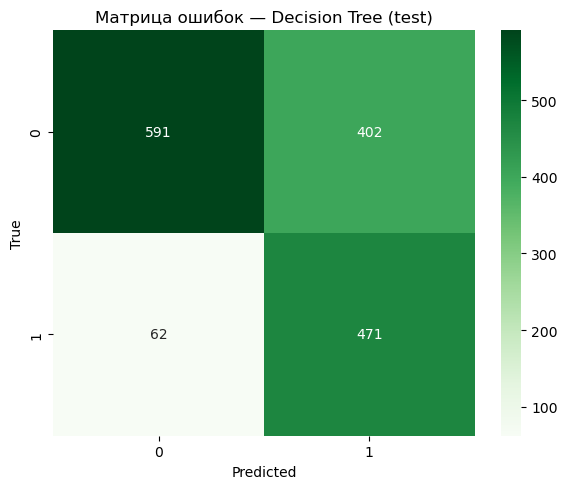

In [31]:
plot_confusion_matrix_simple(y_test, y_pred_test,
                             title="Матрица ошибок — Decision Tree (test)")

# Выводы

**Моделирование:**

Проведена оценка моделей Decision Tree, использующих разные методы для борьбы с дисбалансом классов. Лучший результат по метрике recall для класса 1 показало дерево решений с весами классов. Кроме того, были проведены эксперименты по изменению порога принятия решений и генерации дополнительных признаков.  

**Результаты:**

На тесте выбранная модель (с весами классов, порогом в 0.35 и без доп. признаков) показывает recall класса 1 = 0.88 и precision класса 1 = 0.54, что уступает логистической регрессии (0.89 и 0.58 соответственно), однако при этом дерево решений обладает большей интерпретируемостью. Важнейшие признаки по версии дерева решений: Prothrombin, Copper, Bilirubin, Albumin.